## Tuesday Sep 8 — SeqIO basics

Why "16S ribosomal RNA" specifically: 16S rRNA is a gene present in basically all bacteria, and scientists sequence it constantly because it's used to identify and classify bacterial species

In [1]:
from Bio import SeqIO

In [2]:
records = list(SeqIO.parse("my_sequences.fasta","fasta"))
print(len(records))

20


In [3]:
for a_record in records:
    print(a_record.id)
    print(len(a_record.seq))

M99704.1
1568
PX119937.1
779
PX120102.1
1473
AF182726.1
661
KJ849339.1
1238
PV984494.1
1175
PV257721.1
1369
PP320568.1
1190
OQ826681.1
750
OP881496.1
955
MN559524.1
1003
GQ202654.1
158
PZ626510.1
1147
PX899199.1
1219
PX875355.1
436
PX588624.1
1301
PX518255.1
1062
PX307694.1
1449
PV992292.1
1536
PV937061.1
1202


## Wednesday Sep 9 — Filtering by length

16S ribosomal RNA genes are naturally a few hundred bases minimum, so a 100-base cutoff is not going to catch much in this particular dataset.

In [4]:
filtered_records = []
for record in records:
    if len(record.seq) >= 100:
        filtered_records.append(record)
print(len(filtered_records))

20


In [5]:
count = SeqIO.write(filtered_records,"filtered.fasta","fasta")
print(count)

20


## Thursday Sep 10 — Seq object methods

Learning what a Seq object is and how it differs from a plain string — complement, reverse complement, transcription, translation.

In [6]:
from Bio.Seq import Seq
my_seq = Seq("ATGCATGCATGC")

In [7]:
print(len(my_seq))
print(my_seq[0])
print(my_seq[0:3])

12
A
ATG


In [8]:
print(type(my_seq[0:3]))

<class 'Bio.Seq.Seq'>


In [9]:
print(my_seq.complement())

TACGTACGTACG


In [10]:
print(my_seq.reverse_complement())

GCATGCATGCAT


In [11]:
print(my_seq.transcribe())

AUGCAUGCAUGC


**Side exercise — template vs. coding strand:**
transcribe() on a Seq assumes you're already handing it the coding strand (direct T→U swap).
If you only have the template strand, you must first take its reverse_complement() to get the
coding strand, THEN transcribe(). Tested here: template_strand → reverse_complement() →
coding_strand → transcribe() → mRNA.

In [12]:
template_strand = my_seq
coding_strand = template_strand.reverse_complement()
print(coding_strand)

GCATGCATGCAT


In [13]:
mRNA = coding_strand.transcribe()
print(mRNA)

GCAUGCAUGCAU


In [14]:
print(my_seq.translate())

MHAC


In [15]:
print(coding_strand.translate())

ACMH


translate() also assumes the Seq handed to it is the coding strand/mRNA — same
assumption as transcribe(). Proof: translating my_seq (pretend template) vs
translating coding_strand (correct strand) gave DIFFERENT results —
my_seq.translate() → MHAC, coding_strand.translate() → ACMH.
Same 4 amino acids, different order — confirms strand choice changes the
resulting protein. Lesson: always translate the correct/coding strand for
a result to be biologically meaningful.

### Real gene — Lactobacillus reuteri TetW (tetracycline resistance)
Downloaded from NCBI: strain ATCC 55730, gene TetW (lr1996), complete cds, 1920 bp

In [16]:
tet_records = list(SeqIO.parse("tetW_gene.fasta","fasta"))
print(len(tet_records))

1


In [17]:
tet_seq = tet_records[0].seq
print(tet_records[0].id)
print(len(tet_seq))

EF421935.1
1920


Ran the real TetW gene (tet_seq, 1920 bp, from NCBI) through reverse_complement(),
transcribe(), and translate() — directly on tet_seq, NOT chained, because this
record is already a "complete cds" = coding strand by NCBI convention (no
template-vs-coding ambiguity like the my_seq exercise).

In [18]:
print(tet_seq.reverse_complement())

TTACATTATCTTCTGAAACATATAGCGCACCTTGTCCAGGCGGCTGTTTGGACGGCGGGGCTGGATGACTGGCTTGCCGACAGCGGCCTGATACCCTTTCAGTTCTGTAAGGCATACGCTCTGCCCGTTGGTGTAAGAGGCCAGATCAGTACGGTATGCCTGTATACAGCGGGCGGGAATCTCGCCAGTAAAGACAACTTCATCCTTTTTTACCTGGACCGTTTCGATGGTGGCACAGTATTTCGGTGCATCATGATAAGCCCTGGAAAGATATTCCCGGGGCGCATAGAGGGTGAAGGAGAGATAAGGTTCCAGCAGTTGCGTCCCTGATTCCTTCAATGCCTGTTCCAATACAATCGGGGCCAATGAGCGGAAGTCCGCCGGCGTGCTGACCGGACTGTAATAAAGCCCGTATTCAAAGCAAATCTTACAGTCCGTTACGTTCCAGCCGAACAAGCCCTGCTCCAGCCCGTAACGGATACCATCCCTGACAGCGTTTTGAAAACTCTGGTTCAAGTATCCCAGCGAAACCCGGCTCTCGTATTGTACACCGGAGCCAAGCGGGAGTGGTGTAACAGACAGTCCGATGGATGCCCAAAACGGGTTGGGCGGCACCTCGATATGGATGGTGTGGCTGGCTGCTTTGAGCGGCCGCTCCATATAAATGACGGTGGGTTCCTTTACCACTGTTTCAAGCTTGTATTTTTCCGACAGCAAAGCGGAAACAACCTCCAACTGCACCCGGCCCAAAAAAGAAAGAATGATCTCATGGGTGATGGAATCCACCTCGCAGCGCAAAAGCGGGTCAGTATCCGCAAGTTGCGTAAGAGCGTCCAGCAGCCGTTCTCTTTGCGCTGCCGTTTTCGGCGCAATCGACGTCCGCAGCATGGGGAGGGGGTCCTCACGCCACCTTTTACGAGGGAGCCGGGTTGGGTCCCCTAATACATCGTTTAACCTCACGCTGTCGCTGGGAAGGATAACAATTTCACCCGGATAAGCG

Note: reverse_complement() here is just a standalone demonstration (shows what
the opposite strand looks like) — it is NOT feeding into transcribe()/translate().
Those two methods are called directly on tet_seq itself, since tet_seq is
already the coding strand. Contrast with the earlier my_seq exercise, where
reverse_complement()'s OUTPUT was stored and then deliberately fed into
transcribe() as a real chained pipeline.

In [19]:
print(tet_seq.transcribe())

AUGAAAAUAAUCAAUAUUGGAAUUCUUGCCCAUGUAGACGCUGGAAAGACGACCUUGACGGAGAGCCUGCUAUAUGCCAGCGGAGCCAUUUCAGAACCGGGGAGCGUCAAAAAAGGGACAACGAGGACGGACACCAUGUUUUUGGAGCGGCAGCGUGGGAUUACCAUUCAAGCGGCAGUCACUUCCUUCCAGUGGCACAGAUGUAAAGUCAACAUUGUGGAUACGCCCGGCCACAUGGAUUUUUUGGCGGAGGUGUACCGCUCUUUGGCUGUUUUAGAUGGGGCCAUCUUGGUGAUCUCCGCUAAAGAUGGCGUGCAGGCCCAGACCCGUAUUCUGUUCCAUGCCCUGCGGAAAAUGAACAUUCCCACCGUUAUCUUUAUCAACAAGAUCGACCAGGCUGGCGUUGAUUUGCAGAGCGUGGUUCAGUCUGUUCGGGAUAAGCUCUCCGCCGAUAUUAUCAUCAAGCAGACGGUGUCGCUGUCCCCGGAAAUAGUCCUGGAGGAAAAUACCGACAUAGAAGCAUGGGAUGCGGUCAUCGAAAAUAACGAUAAAUUAUUGGAAAAGUAUAUCGCAGGAGAACCAAUCAGCCGGGAAAAACUUGUGCGGGAGGAACAGCGGCGGGUUCAAGACGCCUCCCUGUUCCCGGUCUAUUAUGGCAGCGCCAAAAAGGGCCUUGGCAUUCAACCGUUGAUGGAUGCGGUGACAGGGCUGUUCCAACCGAUUGGGGAACAGGGGAGCGCCGCCCUAUGCGGCAGCGUUUUCAAGGUGGAGUAUACAGAUUGCGGCCAGCGGCGUGUCUAUCUACGGCUAUACAGCGGAACGCUGCGCCUGCGGGAUACGGUGGCCCUGGCCGGGAGAGAAAAGCUGAAAAUCACAGAGAUGCGUAUUCCAUCCAAAGGGGAAAUUGUUCGGACAGACACCGCUUAUCCGGGUGAAAUUGUUAUCCUUCCCAGCGACAGCGUGAGGUUAAACGAUGUAUUAGGGGACCCAACCCGGCUCC

In [20]:
print(tet_seq.translate())

MKIINIGILAHVDAGKTTLTESLLYASGAISEPGSVKKGTTRTDTMFLERQRGITIQAAVTSFQWHRCKVNIVDTPGHMDFLAEVYRSLAVLDGAILVISAKDGVQAQTRILFHALRKMNIPTVIFINKIDQAGVDLQSVVQSVRDKLSADIIIKQTVSLSPEIVLEENTDIEAWDAVIENNDKLLEKYIAGEPISREKLVREEQRRVQDASLFPVYYGSAKKGLGIQPLMDAVTGLFQPIGEQGSAALCGSVFKVEYTDCGQRRVYLRLYSGTLRLRDTVALAGREKLKITEMRIPSKGEIVRTDTAYPGEIVILPSDSVRLNDVLGDPTRLPRKRWREDPLPMLRTSIAPKTAAQRERLLDALTQLADTDPLLRCEVDSITHEIILSFLGRVQLEVVSALLSEKYKLETVVKEPTVIYMERPLKAASHTIHIEVPPNPFWASIGLSVTPLPLGSGVQYESRVSLGYLNQSFQNAVRDGIRYGLEQGLFGWNVTDCKICFEYGLYYSPVSTPADFRSLAPIVLEQALKESGTQLLEPYLSFTLYAPREYLSRAYHDAPKYCATIETVQVKKDEVVFTGEIPARCIQAYRTDLASYTNGQSVCLTELKGYQAAVGKPVIQPRRPNSRLDKVRYMFQKIM*


Sanity check: translated protein starts with M (= ATG = biological start codon)
and ends with * (stop codon marker) — confirms this is a real, correctly-oriented,
complete coding sequence, matching expectations for a "complete cds" record.

### Friday Sep 11 — find_orfs function

In [21]:
def find_orfs(sequence):
    orfs = []
    i = 0 
    while i < len(sequence):
        codon = sequence[i:i+3]
        if codon == 'ATG':
            j = i
            while j < len(sequence):
                stop_codon = sequence[j:j+3]
                if stop_codon in ['TAA','TAG','TGA']:
                    orfs.append(sequence[i:j+3])
                    i = j+3
                    break
                j =j+3
        else:
            i = i+1
    return orfs

In [22]:
result = find_orfs("ATGCGATAAATGTTTTGA")
print(result)

['ATGCGATAA', 'ATGTTTTGA']


find_orfs(sequence) — scans for every ATG, reads forward in codons of 3 until a
stop codon (TAA/TAG/TGA), saves that chunk, then resumes scanning right after
the stop codon (not one letter at a time — jumps past the whole ORF).
Uses a while loop (not for/range) because the jump size after each ORF is
variable and depends on where the stop codon is found — for/range can't do
this since reassigning the loop variable inside a for loop is silently ignored.
Tested: find_orfs("ATGCGATAAATGTTTTGA") → ['ATGCGATAA', 'ATGTTTTGA'] matches
expected output.

## Saturday Sep 12 — GC content

In [23]:
from Bio.SeqUtils import gc_fraction

In [24]:
gc_f = gc_fraction(records[0].seq)
print(gc_f)

0.5185185185185185


In [25]:
gc_percent = gc_f*100
print(gc_percent)

51.85185185185185


In [26]:
gc_percent_records = []
for gc_records in records:
    gc_percent = gc_fraction(gc_records.seq)*100
    gc_percent_records.append(gc_percent)
print(len(gc_percent_records))

20


In [27]:
print(gc_percent_records)

[51.85185185185185, 52.374839537869065, 53.49626612355737, 46.59606656580938, 53.392568659127626, 52.255319148936174, 53.3235938641344, 52.85714285714286, 51.6, 54.76439790575917, 52.74177467597209, 46.835443037974684, 53.44376634699215, 52.83483976992605, 53.899082568807344, 52.88239815526518, 52.54237288135594, 53.38865836791148, 53.997378768020965, 52.74542429284526]


In [28]:
highest_gc_content = max(gc_percent_records)
lowest_gc_content = min(gc_percent_records)
print(highest_gc_content)
print(lowest_gc_content)

54.76439790575917
46.59606656580938


In [29]:
highest_position = gc_percent_records.index(highest_gc_content)
print(highest_position)
print(records[highest_position].id)

9
OP881496.1


In [30]:
lowest_position = gc_percent_records.index(lowest_gc_content)
print(lowest_position)
print(records[lowest_position].id)

3
AF182726.1


Calculated GC content for all 20 sequences using gc_fraction() from Bio.SeqUtils (returns a fraction 0–1, multiplied by 100 for percentage). Built a parallel list (gc_percent_records) alongside the original records list using the same accumulator pattern from Wednesday's filter — same loop order means matching positions across both lists. Used built-in max()/min() (plain Python, not Biopython) to find highest/lowest GC%, then .index() to trace each value's position back to its original record ID (highest: OP881496.1 at 54.76%, lowest: AF182726.1 at 46.60%).

In [31]:
import matplotlib.pyplot as plt

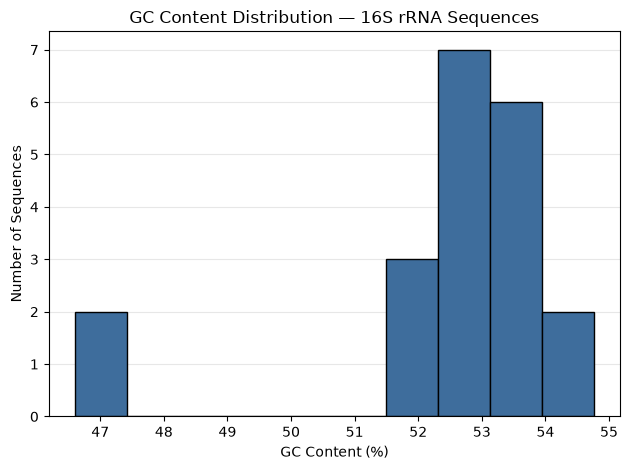

In [32]:
plt.hist(gc_percent_records, bins=10, edgecolor="black",color="#3E6D9C",zorder=2)
plt.xlabel("GC Content (%)")
plt.ylabel("Number of Sequences")
plt.title("GC Content Distribution — 16S rRNA Sequences")
plt.grid(axis='y', alpha=0.3,zorder=0)
plt.tight_layout()
plt.savefig("gc_content_histogram.png")
plt.show()

Plotted a histogram with Matplotlib showing the distribution — revealed two distinct clusters rather than a smooth spread: a small low-GC group (~47%) and the bulk clustered 52-55%. Saved as gc_content_histogram.png.

## Sunday Sep 13 — SeqIO + Pandas

Moving from parallel lists to a proper table structure using Pandas DataFrames.

In [52]:
import pandas as pd 

In [53]:
one_row_check = {"id":records[0].id,"length":len(records[0].seq),"gc_percent":gc_fraction(records[0].seq)*100}
print(one_row_check)

{'id': 'M99704.1', 'length': 1568, 'gc_percent': 51.85185185185185}


In [54]:
dataframe_list = []
for record in records:
    each_record ={"id":record.id,"length":len(record.seq),"gc_percent":gc_fraction(record.seq)*100}
    dataframe_list.append(each_record)
print(len(dataframe_list))

20


In [55]:
print(dataframe_list[0])

{'id': 'M99704.1', 'length': 1568, 'gc_percent': 51.85185185185185}


In [56]:
df = pd.DataFrame(dataframe_list)
df

,id,length,gc_percent
0,M99704.1,1568,51.851852
1,PX119937.1,779,52.374840
2,PX120102.1,1473,53.496266
3,AF182726.1,661,46.596067
4,KJ849339.1,1238,53.392569
5,PV984494.1,1175,52.255319
6,PV257721.1,1369,53.323594
7,PP320568.1,1190,52.857143
8,OQ826681.1,750,51.600000
9,OP881496.1,955,54.764398


In [57]:
df.shape

(20, 3)

Built a list of dictionaries — one dict per record, with id, length, gc_percent — using the same accumulator loop pattern as before, but storing structured rows instead of a single value. Fed that list into pd.DataFrame() to build a proper table, with dict keys becoming column names automatically.

In [58]:
filtered_length = df[df["length"]>500]
filtered_length

,id,length,gc_percent
0,M99704.1,1568,51.851852
1,PX119937.1,779,52.374840
2,PX120102.1,1473,53.496266
3,AF182726.1,661,46.596067
4,KJ849339.1,1238,53.392569
5,PV984494.1,1175,52.255319
6,PV257721.1,1369,53.323594
7,PP320568.1,1190,52.857143
8,OQ826681.1,750,51.600000
9,OP881496.1,955,54.764398


In [59]:
filtered_length.shape

(18, 3)

In [60]:
sorted_df = filtered_length.sort_values(by="gc_percent",ascending=False)
sorted_df

,id,length,gc_percent
9,OP881496.1,955,54.764398
18,PV992292.1,1536,53.997379
2,PX120102.1,1473,53.496266
12,PZ626510.1,1147,53.443766
4,KJ849339.1,1238,53.392569
17,PX307694.1,1449,53.388658
6,PV257721.1,1369,53.323594
15,PX588624.1,1301,52.882398
7,PP320568.1,1190,52.857143
13,PX899199.1,1219,52.834840


Filtered using df[df["length"] > 500] (boolean masking — comparing a whole column at once produces True/False per row, then keeping only True rows), no loop required. Sorted with .sort_values("gc_percent", ascending=False). Noted that pandas preserves each row's original index number through both filtering and sorting, rather than renumbering — useful for tracing rows back to their source.

Highest GC content among sequences >500 bases: OP881496.1 at 54.76%.